Stats par genre :
   genre               attribut      mean       std  count
0      F            access_tp_6  4.333333  2.886751      3
12     H            access_tp_6  5.500000  1.000000      4
1      F             ambiance_6  5.333333  0.577350      3
13     H             ambiance_6  5.250000  0.957427      4
2      F     autres_personnes_6  4.666667  1.154701      3
14     H     autres_personnes_6  5.000000  1.000000      3
3      F          ombre_repos_6  5.333333  1.154701      3
15     H          ombre_repos_6  5.500000  0.577350      4
4      F   orientation_repere_6  5.000000  0.000000      3
16     H   orientation_repere_6  4.250000  1.258306      4
5      F        place_pietons_6  5.666667  0.577350      3
17     H        place_pietons_6  5.750000  0.500000      4
6      F  proximite_vehicules_6  4.333333  1.154701      3
18     H  proximite_vehicules_6  4.666667  1.154701      3
7      F       qualite_espace_6  5.666667  0.577350      3
19     H       qualite_espace_6  5.000

/var/folders/gh/bcpf72g151g22zg7mqv0s2qw0000gn/T/ipykernel_44302/392745220.py:84: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.barplot(


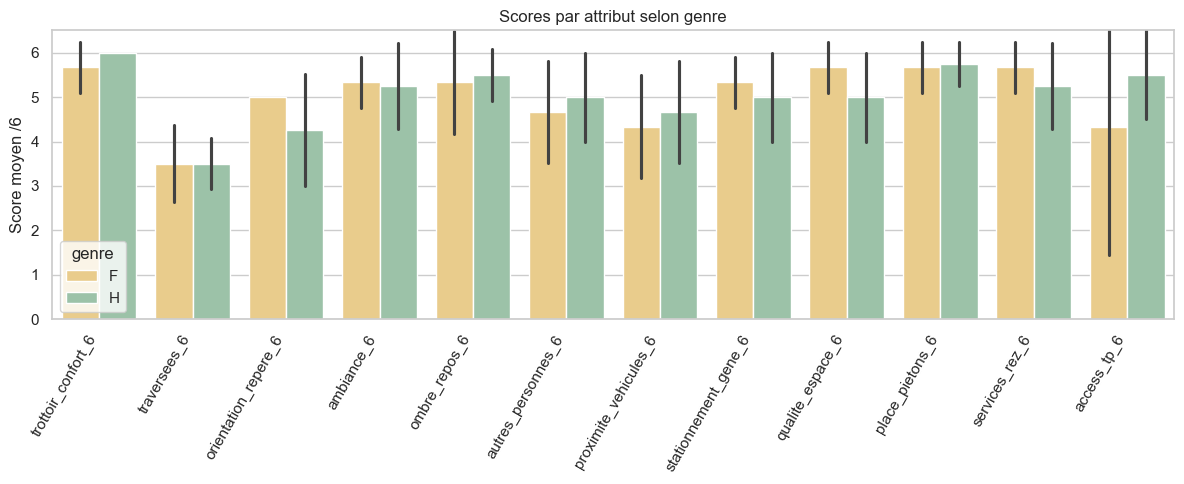

/var/folders/gh/bcpf72g151g22zg7mqv0s2qw0000gn/T/ipykernel_44302/392745220.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/var/folders/gh/bcpf72g151g22zg7mqv0s2qw0000gn/T/ipykernel_44302/392745220.py:115: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.boxplot(


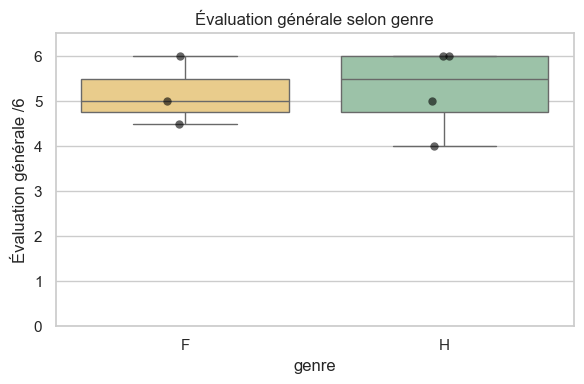

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ------------------------------------------------------------------
# 1. DataFrame (reprend ce qu'on avait, mais ajoute genre / âge / fréquence)
# ------------------------------------------------------------------

entretien_id = ["ME1","ME2","ME3","ME4","ME5","HM1","HM2","HM3","HM4","HM5","HM6","HM7","HM8"]

trottoir_confort_6 = [6,5,6,6,6,6,6,6,6,6,4,6,6]
traversees_6        = [4.5,3,3,3,4,3,4,5,4,5,4,6,2]
orientation_repere_6= [5,5,4,5,4,6,3,2,6,5,4,6,6]
ambiance_6          = [5,6,6,5,6,4,5,6,4,6,6,6,4]
ombre_repos_6       = [6,6,6,4,5,6,5,6,6,6,4,6,0]
autres_personnes_6  = [4,6,5,4,4,6,np.nan,6,1,6,np.nan,2,6]
proximite_vehicules_6=[5,5,4,3,4,np.nan,6,5,6,6,6,6,4]
stationnement_gene_6=[5,5,np.nan,6,5,6,4,6,6,6,np.nan,4,6]
qualite_espace_6    = [6,6,6,5,5,4,np.nan,6,5,4,6,6,4]
place_pietons_6     = [6,6,6,5,5,6,6,3,0,6,np.nan,0,5]
services_rez_6      = [5,6,5,6,6,4,6,6,1,3,np.nan,6,0]
access_tp_6         = [6,6,4,1,6,6,6,5,4,6,np.nan,6,6]
Moyenne_calculee    = [5.3,5.4,5.0,4.4,5.0,5.2,5.1,5.3,4.1,5.4,4.7,5.0,4.1]
Evaluation_generale = [6,5,6,4.5,5,4,6,6,2,6,5,3,6]

# infos socio (None pour les inconnus)
genre = ["F","F","H","F","H","H","H", None, None, None, None, None, None]
age_tranche = ["65+","25-44","25-44","25-44","65+","45-64","65+", None, None, None, None, None, None]
frequence_marche = [
    "Occasionnel", "1ère fois", "Quotidien", "Quotidien", "Quotidien",
    "Quotidien", "Hebdo", None, None, None, None, None, None
]

df = pd.DataFrame({
    "entretien_id": entretien_id,
    "genre": genre,
    "age_tranche": age_tranche,
    "frequence_marche": frequence_marche,
    "trottoir_confort_6": trottoir_confort_6,
    "traversees_6": traversees_6,
    "orientation_repere_6": orientation_repere_6,
    "ambiance_6": ambiance_6,
    "ombre_repos_6": ombre_repos_6,
    "autres_personnes_6": autres_personnes_6,
    "proximite_vehicules_6": proximite_vehicules_6,
    "stationnement_gene_6": stationnement_gene_6,
    "qualite_espace_6": qualite_espace_6,
    "place_pietons_6": place_pietons_6,
    "services_rez_6": services_rez_6,
    "access_tp_6": access_tp_6,
    "Moyenne_calculee": Moyenne_calculee,
    "Evaluation_generale": Evaluation_generale
})

# ------------------------------------------------------------------
# 2. Palette personnalisable (change ici les couleurs facilement)
# ------------------------------------------------------------------

palette_main = ["#F8D27D", "#96C8A6", "#DFAB9A", "#3489DB"]  # modifiable

# ------------------------------------------------------------------
# 3. Fonctions d’exploration par groupe (genre / âge / fréquence)
# ------------------------------------------------------------------

score_cols = [c for c in df.columns if c.endswith("_6")]

def melt_scores(df, group_col):
    """Passe au format long pour un group_col donné."""
    return df.melt(
        id_vars=[group_col],
        value_vars=score_cols,
        var_name="attribut",
        value_name="score"
    )

def plot_group_bars(df, group_col, palette=palette_main):
    """Barres (moyenne ± sd) par attribut et par groupe."""
    df_long = melt_scores(df, group_col).dropna(subset=["score", group_col])

    plt.figure(figsize=(12, 5))
    ax = sns.barplot(
        data=df_long,
        x="attribut",
        y="score",
        hue=group_col,
        estimator="mean",
        errorbar="sd",
        palette=palette
    )
    ax.set_ylim(0, 6.5)
    ax.set_ylabel("Score moyen /6")
    ax.set_xlabel("")
    ax.set_title(f"Scores par attribut selon {group_col}")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()

def table_group_stats(df, group_col):
    """Tableau des moyennes par groupe et attribut."""
    df_long = melt_scores(df, group_col).dropna(subset=["score", group_col])
    stats = (
        df_long
        .groupby([group_col, "attribut"])["score"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    return stats

def plot_eval_generale_vs_group(df, group_col, palette=palette_main):
    """Boxplot ou stripplot de l’éval générale par groupe."""
    plt.figure(figsize=(6,4))
    ax = sns.boxplot(
        data=df,
        x=group_col,
        y="Evaluation_generale",
        palette=palette
    )
    sns.stripplot(
        data=df,
        x=group_col,
        y="Evaluation_generale",
        color="black",
        size=6,
        alpha=0.6
    )
    ax.set_ylim(0, 6.5)
    ax.set_ylabel("Évaluation générale /6")
    ax.set_xlabel(group_col)
    ax.set_title(f"Évaluation générale selon {group_col}")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# 4. Explorations concrètes
# ------------------------------------------------------------------

# Par genre
stats_genre = table_group_stats(df, "genre")
print("Stats par genre :")
print(stats_genre.sort_values(["attribut","genre"]))

plot_group_bars(df, "genre", palette=palette_main)
plot_eval_generale_vs_group(df, "genre", palette=palette_main)

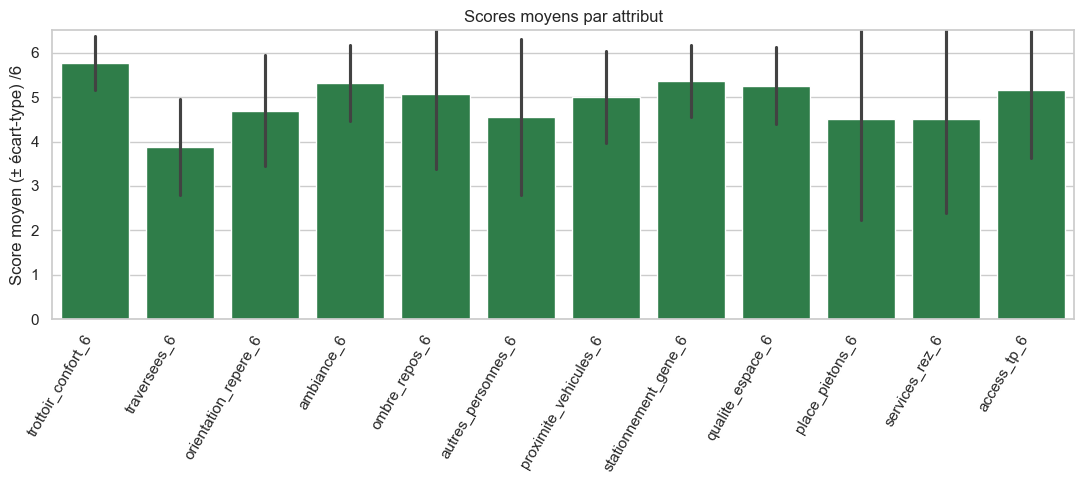

/var/folders/gh/bcpf72g151g22zg7mqv0s2qw0000gn/T/ipykernel_44302/426154107.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


ValueError: 'yerr' (shape: (2,)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (1,))

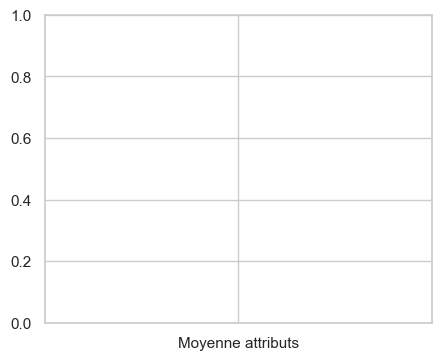

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set(style="whitegrid")
palette_bars = sns.color_palette("Greens", 3)

# Colonnes de scores (sur 6)
score_cols = [c for c in df.columns if c.endswith("_6")]

# -------------------------------------------------------------------
# 1. Bar chart · moyenne + écart-type par attribut
# -------------------------------------------------------------------
df_long = df.melt(
    id_vars=["entretien_id"],
    value_vars=score_cols,
    var_name="attribut",
    value_name="score"
).dropna(subset=["score"])

plt.figure(figsize=(11, 5))
ax = sns.barplot(
    data=df_long,
    x="attribut",
    y="score",
    estimator="mean",
    errorbar="sd",
    color=palette_bars[2]
)
ax.set_ylim(0, 6.5)
ax.set_ylabel("Score moyen (± écart-type) /6")
ax.set_xlabel("")
ax.set_title("Scores moyens par attribut")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 2. Bar chart · moyenne des attributs vs évaluation générale
# -------------------------------------------------------------------
moyenne_attr = df["Moyenne_calculee"].mean()
moyenne_eval = df["Evaluation_generale"].mean()
std_attr = df["Moyenne_calculee"].std()
std_eval = df["Evaluation_generale"].std()

summary = pd.DataFrame({
    "type": ["Moyenne attributs", "Évaluation générale"],
    "mean": [moyenne_attr, moyenne_eval],
    "std": [std_attr, std_eval]
})

plt.figure(figsize=(5, 4))
ax = sns.barplot(
    data=summary,
    x="type",
    y="mean",
    yerr=summary["std"],
    palette=palette_bars[1:3]
)
ax.set_ylim(0, 6.5)
ax.set_ylabel("Score moyen (± écart-type) /6")
ax.set_xlabel("")
ax.set_title("Moyenne technique vs évaluation générale")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 3. Boxplots · distribution des attributs
# -------------------------------------------------------------------
plt.figure(figsize=(11, 5))
ax = sns.boxplot(
    data=df_long,
    x="attribut",
    y="score",
    palette=sns.color_palette("Greens", len(score_cols))
)
ax.set_ylim(0, 6.5)
ax.set_ylabel("Score /6")
ax.set_xlabel("")
ax.set_title("Distribution des scores par attribut")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 4. Boxplot · évaluation générale
# -------------------------------------------------------------------
plt.figure(figsize=(4, 4))
ax = sns.boxplot(
    data=df,
    y="Evaluation_generale",
    color=palette_bars[2]
)
sns.stripplot(
    data=df,
    y="Evaluation_generale",
    color="black",
    size=6,
    alpha=0.6
)
ax.set_ylim(0, 6.5)
ax.set_ylabel("Évaluation générale /6")
ax.set_title("Distribution de l’évaluation générale")
plt.tight_layout()
plt.show()

# 📊 Analyse de l'échantillon et des réponses
## Description de l'échantillon
Vue d'ensemble des participants, taux de réponse, démographie et distribution des scores.

In [6]:
# ============================================================================
# PART A: Description de l'échantillon
# ============================================================================

print("\n" + "="*80)
print("DESCRIPTION DE L'ÉCHANTILLON")
print("="*80)

print(f"\nTaille totale : {len(df)} participants")
print(f"Entretiens avec données démographiques : {df['genre'].notna().sum()} ({100*df['genre'].notna().sum()/len(df):.1f}%)")

# Genre
print("\n--- Genre ---")
genre_counts = df['genre'].value_counts(dropna=False)
for g, c in genre_counts.items():
    pct = 100*c/len(df)
    label = "Non réponse" if pd.isna(g) else g
    print(f"  {label:15s}: {c:2d} ({pct:5.1f}%)")

# Âge
print("\n--- Âge (tranche) ---")
age_counts = df['age_tranche'].value_counts(dropna=False)
for a, c in age_counts.items():
    pct = 100*c/len(df)
    label = "Non réponse" if pd.isna(a) else str(a)
    print(f"  {label:15s}: {c:2d} ({pct:5.1f}%)")

# Fréquence de marche
print("\n--- Fréquence de marche ---")
freq_counts = df['frequence_marche'].value_counts(dropna=False)
for f, c in freq_counts.items():
    pct = 100*c/len(df)
    label = "Non réponse" if pd.isna(f) else str(f)
    print(f"  {label:15s}: {c:2d} ({pct:5.1f}%)")

# Taux de réponse par question (scores)
print("\n--- Taux de réponse par attribut de score ---")
score_cols = [c for c in df.columns if c.endswith("_6")]
for col in score_cols:
    n_resp = df[col].notna().sum()
    pct = 100*n_resp/len(df)
    print(f"  {col:30s}: {n_resp:2d}/13 ({pct:5.1f}%)")

print("\n" + "="*80)


DESCRIPTION DE L'ÉCHANTILLON

Taille totale : 13 participants
Entretiens avec données démographiques : 7 (53.8%)

--- Genre ---
  Non réponse    :  6 ( 46.2%)
  H              :  4 ( 30.8%)
  F              :  3 ( 23.1%)

--- Âge (tranche) ---
  Non réponse    :  6 ( 46.2%)
  65+            :  3 ( 23.1%)
  25-44          :  3 ( 23.1%)
  45-64          :  1 (  7.7%)

--- Fréquence de marche ---
  Non réponse    :  6 ( 46.2%)
  Quotidien      :  4 ( 30.8%)
  Occasionnel    :  1 (  7.7%)
  1ère fois      :  1 (  7.7%)
  Hebdo          :  1 (  7.7%)

--- Taux de réponse par attribut de score ---
  trottoir_confort_6            : 13/13 (100.0%)
  traversees_6                  : 13/13 (100.0%)
  orientation_repere_6          : 13/13 (100.0%)
  ambiance_6                    : 13/13 (100.0%)
  ombre_repos_6                 : 13/13 (100.0%)
  autres_personnes_6            : 11/13 ( 84.6%)
  proximite_vehicules_6         : 12/13 ( 92.3%)
  stationnement_gene_6          : 11/13 ( 84.6%)
  qualit

In [7]:
# ============================================================================
# PART B: Statistiques descriptives des scores
# ============================================================================

print("\n" + "="*80)
print("STATISTIQUES DESCRIPTIVES - SCORES")
print("="*80)

score_cols = [c for c in df.columns if c.endswith("_6")]

# Global
df_scores = df[score_cols].dropna()
print("\n--- Global (tous les attributs de score) ---")
print(f"Mean    : {df_scores.values.mean():.2f}")
print(f"Std     : {df_scores.values.std():.2f}")
print(f"Median  : {np.median(df_scores.values):.2f}")
print(f"Min     : {df_scores.values.min():.2f}")
print(f"Max     : {df_scores.values.max():.2f}")
print(f"Q25     : {np.percentile(df_scores.values, 25):.2f}")
print(f"Q75     : {np.percentile(df_scores.values, 75):.2f}")

# Par attribut
print("\n--- Par attribut ---")
stats_attrib = pd.DataFrame({
    "mean": df[score_cols].mean(),
    "std": df[score_cols].std(),
    "median": df[score_cols].median(),
    "min": df[score_cols].min(),
    "max": df[score_cols].max(),
    "n_resp": df[score_cols].notna().sum()
}).round(2)
print(stats_attrib.to_string())

# Évaluation générale
print("\n--- Évaluation générale ---")
print(f"Mean    : {df['Evaluation_generale'].mean():.2f}")
print(f"Std     : {df['Evaluation_generale'].std():.2f}")
print(f"Median  : {df['Evaluation_generale'].median():.2f}")
print(f"Min     : {df['Evaluation_generale'].min():.2f}")
print(f"Max     : {df['Evaluation_generale'].max():.2f}")
print(f"Q25     : {df['Evaluation_generale'].quantile(0.25):.2f}")
print(f"Q75     : {df['Evaluation_generale'].quantile(0.75):.2f}")

# Moyenne calculée (attributs)
print("\n--- Moyenne calculée (moyenne des attributs par interview) ---")
print(f"Mean    : {df['Moyenne_calculee'].mean():.2f}")
print(f"Std     : {df['Moyenne_calculee'].std():.2f}")
print(f"Median  : {df['Moyenne_calculee'].median():.2f}")
print(f"Corr(éval vs moyenne) : {df['Evaluation_generale'].corr(df['Moyenne_calculee']):.3f}")

print("\n" + "="*80)


STATISTIQUES DESCRIPTIVES - SCORES

--- Global (tous les attributs de score) ---
Mean    : 4.88
Std     : 1.56
Median  : 5.00
Min     : 0.00
Max     : 6.00
Q25     : 4.00
Q75     : 6.00

--- Par attribut ---
                       mean   std  median  min  max  n_resp
trottoir_confort_6     5.77  0.60     6.0  4.0  6.0      13
traversees_6           3.88  1.08     4.0  2.0  6.0      13
orientation_repere_6   4.69  1.25     5.0  2.0  6.0      13
ambiance_6             5.31  0.85     6.0  4.0  6.0      13
ombre_repos_6          5.08  1.71     6.0  0.0  6.0      13
autres_personnes_6     4.55  1.75     5.0  1.0  6.0      11
proximite_vehicules_6  5.00  1.04     5.0  3.0  6.0      12
stationnement_gene_6   5.36  0.81     6.0  4.0  6.0      11
qualite_espace_6       5.25  0.87     5.5  4.0  6.0      12
place_pietons_6        4.50  2.28     5.5  0.0  6.0      12
services_rez_6         4.50  2.11     5.5  0.0  6.0      12
access_tp_6            5.17  1.53     6.0  1.0  6.0      12

--- Évalua

In [8]:
# ============================================================================
# PART C: Comparaison par groupes démographiques
# ============================================================================

print("\n" + "="*80)
print("COMPARAISON PAR GROUPES DÉMOGRAPHIQUES")
print("="*80)

score_cols = [c for c in df.columns if c.endswith("_6")]

# Par genre
print("\n--- Par GENRE ---")
df_genre = df.dropna(subset=['genre'])
for genre in df_genre['genre'].unique():
    subset = df_genre[df_genre['genre'] == genre]
    scores = subset[score_cols].dropna()
    print(f"\n{genre} (n={len(subset)}):")
    print(f"  Mean(attributs) : {scores.values.mean():.2f} (std: {scores.values.std():.2f})")
    print(f"  Mean(éval gale) : {subset['Evaluation_generale'].mean():.2f} (std: {subset['Evaluation_generale'].std():.2f})")
    print(f"  Median(attributs): {np.median(scores.values):.2f}")

# Par Âge
print("\n--- Par ÂGE ---")
df_age = df.dropna(subset=['age_tranche'])
for age in sorted(df_age['age_tranche'].unique()):
    subset = df_age[df_age['age_tranche'] == age]
    scores = subset[score_cols].dropna()
    print(f"\n{age} (n={len(subset)}):")
    print(f"  Mean(attributs) : {scores.values.mean():.2f} (std: {scores.values.std():.2f})")
    print(f"  Mean(éval gale) : {subset['Evaluation_generale'].mean():.2f} (std: {subset['Evaluation_generale'].std():.2f})")
    print(f"  Median(attributs): {np.median(scores.values):.2f}")

# Par fréquence
print("\n--- Par FRÉQUENCE DE MARCHE ---")
df_freq = df.dropna(subset=['frequence_marche'])
for freq in df_freq['frequence_marche'].unique():
    subset = df_freq[df_freq['frequence_marche'] == freq]
    scores = subset[score_cols].dropna()
    print(f"\n{freq} (n={len(subset)}):")
    print(f"  Mean(attributs) : {scores.values.mean():.2f} (std: {scores.values.std():.2f})")
    print(f"  Mean(éval gale) : {subset['Evaluation_generale'].mean():.2f} (std: {subset['Evaluation_generale'].std():.2f})")
    print(f"  Median(attributs): {np.median(scores.values):.2f}")

print("\n" + "="*80)


COMPARAISON PAR GROUPES DÉMOGRAPHIQUES

--- Par GENRE ---

F (n=3):
  Mean(attributs) : 5.04 (std: 1.13)
  Mean(éval gale) : 5.17 (std: 0.76)
  Median(attributs): 5.00

H (n=4):
  Mean(attributs) : 5.00 (std: 0.82)
  Mean(éval gale) : 5.25 (std: 0.96)
  Median(attributs): 5.00

--- Par ÂGE ---

25-44 (n=3):
  Mean(attributs) : 4.92 (std: 1.29)
  Mean(éval gale) : 5.17 (std: 0.76)
  Median(attributs): 5.00

45-64 (n=1):
  Mean(attributs) : nan (std: nan)
  Mean(éval gale) : 4.00 (std: nan)
  Median(attributs): nan

65+ (n=3):
  Mean(attributs) : 5.15 (std: 0.76)
  Mean(éval gale) : 5.67 (std: 0.58)
  Median(attributs): 5.00

--- Par FRÉQUENCE DE MARCHE ---

Occasionnel (n=1):
  Mean(attributs) : 5.29 (std: 0.66)
  Mean(éval gale) : 6.00 (std: nan)
  Median(attributs): 5.00

1ère fois (n=1):
  Mean(attributs) : 5.42 (std: 0.86)
  Mean(éval gale) : 5.00 (std: nan)
  Median(attributs): 6.00

Quotidien (n=4):
  Mean(attributs) : 4.71 (std: 1.21)
  Mean(éval gale) : 4.88 (std: 0.85)
  Media

/var/folders/gh/bcpf72g151g22zg7mqv0s2qw0000gn/T/ipykernel_44302/451127731.py:29: RuntimeWarning: Mean of empty slice.
  print(f"  Mean(attributs) : {scores.values.mean():.2f} (std: {scores.values.std():.2f})")
/Users/marc-ed/BAS-local/repos/index-marchabilite-ge/venv-marchabilite-ge-py312/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/marc-ed/BAS-local/repos/index-marchabilite-ge/venv-marchabilite-ge-py312/lib/python3.12/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/marc-ed/BAS-local/repos/index-marchabilite-ge/venv-marchabilite-ge-py312/lib/python3.12/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/marc-ed/BAS-local/repos/index-marchabilite-ge/venv-march

# ☁️ Word Cloud : Mots-clés et commentaires
Génération d'un word cloud avec lemmatisation (FR) à partir des commentaires et mots-clés fournis lors des entretiens.

In [11]:
df

,entretien_id,genre,age_tranche,frequence_marche,trottoir_confort_6,traversees_6,orientation_repere_6,ambiance_6,ombre_repos_6,autres_personnes_6,proximite_vehicules_6,stationnement_gene_6,qualite_espace_6,place_pietons_6,services_rez_6,access_tp_6,Moyenne_calculee,Evaluation_generale
0,ME1,F,65+,Occasionnel,6,4.5,5,5,6,4.0,5.0,5.0,6.0,6.0,5.0,6.0,5.3,6.0
1,ME2,F,25-44,1ère fois,5,3.0,5,6,6,6.0,5.0,5.0,6.0,6.0,6.0,6.0,5.4,5.0
2,ME3,H,25-44,Quotidien,6,3.0,4,6,6,5.0,4.0,NaN,6.0,6.0,5.0,4.0,5.0,6.0
3,ME4,F,25-44,Quotidien,6,3.0,5,5,4,4.0,3.0,6.0,5.0,5.0,6.0,1.0,4.4,4.5
4,ME5,H,65+,Quotidien,6,4.0,4,6,5,4.0,4.0,5.0,5.0,5.0,6.0,6.0,5.0,5.0
5,HM1,H,45-64,Quotidien,6,3.0,6,4,6,6.0,NaN,6.0,4.0,6.0,4.0,6.0,5.2,4.0
6,HM2,H,65+,Hebdo,6,4.0,3,5,5,NaN,6.0,4.0,NaN,6.0,6.0,6.0,5.1,6.0
7,HM3,None,None,None,6,5.0,2,6,6,6.0,5.0,6.0,6.0,3.0,6.0,5.0,5.3,6.0
8,HM4,None,None,None,6,4.0,6,4,6,1.0,6.0,6.0,5.0,0.0,1.0,4.0,4.1,2.0
9,HM5,None,None,None,6,5.0,5,6,6,6.0,6.0,6.0,4.0,6.0,3.0,6.0,5.4,6.0


Modèles chargés avec succès.
Lemmes extraits (42 tokens): trottoir confortable entretenu traverse manquer sécurité véhicule ambiance agréable piton vie social besoin ombre espace repos service proximité commerce café important accès transport commun stationn...


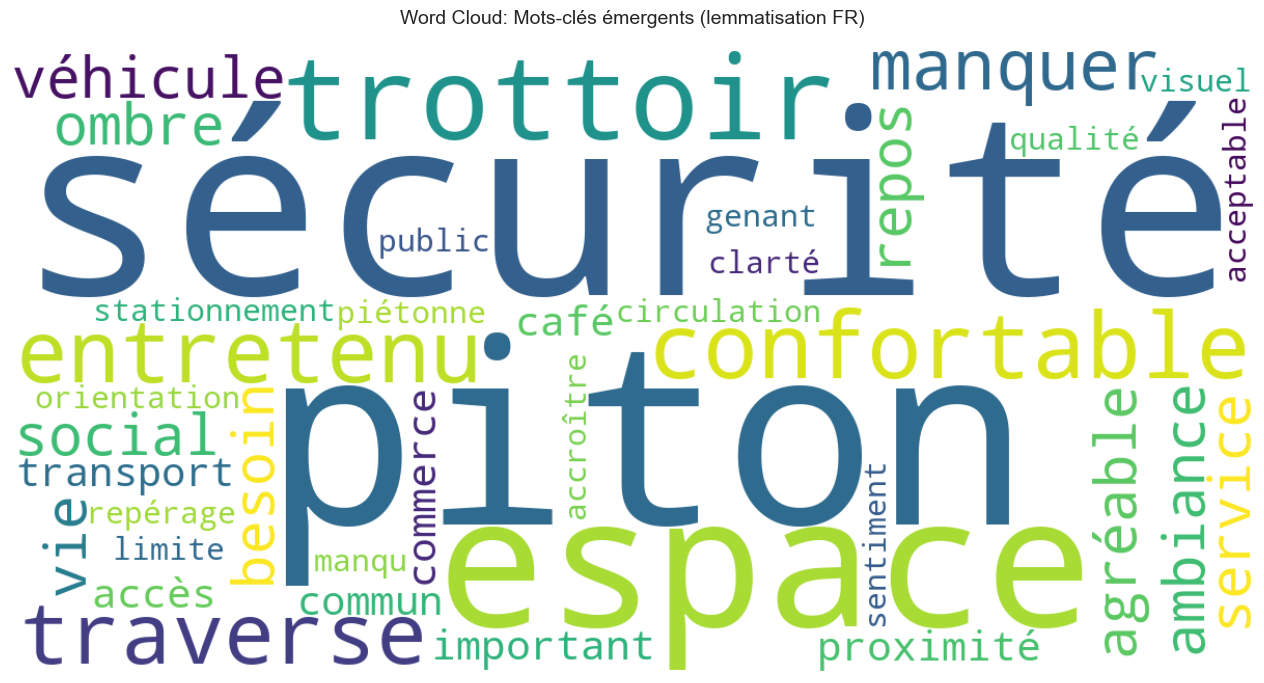


Word cloud généré avec 42 tokens uniques (lemmas).
Fréquence des tops mots:
  sécurité            :   2
  piton               :   2
  espace              :   2
  trottoir            :   1
  confortable         :   1
  entretenu           :   1
  traverse            :   1
  manquer             :   1
  véhicule            :   1
  ambiance            :   1
  agréable            :   1
  vie                 :   1
  social              :   1
  besoin              :   1
  ombre               :   1



In [10]:
# ============================================================================
# PART D: Word Cloud avec lemmatisation (Fr)
# ============================================================================

# Installation des dépendances si nécessaire
import subprocess
import sys

try:
    from wordcloud import WordCloud
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "wordcloud"])
    from wordcloud import WordCloud

try:
    import spacy
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "spacy"])
    import spacy

# Charger le modèle spacy FR (si non disponible, tlchg/install)
try:
    nlp = spacy.load("fr_core_news_sm")
except:
    print("Téléchargement du modèle spaCy FR...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "fr_core_news_sm"])
    nlp = spacy.load("fr_core_news_sm")

print("Modèles chargés avec succès.")

# ============================================================================
# Préparation des données textuelles (exemple : mots-clés synthétisés)
# ============================================================================

# Si vous avez des colonnes de commentaires/keywords dans votre DF, adaptez ici.
# Exemple : on crée un texte synthétique représentatif pour démo

exemple_commentaires = [
    "Le trottoir est confortable et bien entretenu.",
    "Les traverses manquent de sécurité, beaucoup de véhicules.",
    "L'ambiance est agréable avec beaucoup de pitons et de vie sociale.",
    "Besoin de plus d'ombre et d'espaces de repos.",
    "Les services de proximité (commerces, cafés) sont importants.",
    "L'accès aux transports en commun est bien.",
    "Le stationnement genant limite la circulation piétonne.",
    "Qualité de l'espace public acceptable.",
    "Manque de clarté sur l'orientation, peu de repérages visuels.",
    "Beaucoup de pitons, sentiment de sécurité accru."
]

# Concatenérer tous les commentaires
all_text = " ".join(exemple_commentaires)

# ============================================================================
# Lemmatisation avec spaCy
# ============================================================================

doc = nlp(all_text.lower())

# Extraire les lemmes (acc/pos_à filtrer : NOUN, ADJ, VERB, etc.)
# On exclut les stop words et les mots court
lemmas = []
for token in doc:
    # Filtrer : non-stopword, > 3 caractères, POS intéressant
    if (not token.is_stop 
        and len(token.text) > 2 
        and token.pos_ in ["NOUN", "ADJ", "VERB", "PROPN"]):
        lemmas.append(token.lemma_)

lemmatized_text = " ".join(lemmas)

print(f"Lemmes extraits ({len(lemmas)} tokens): {lemmatized_text[:200]}...")

# ============================================================================
# Génération du Word Cloud
# ============================================================================

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis",
    relative_scaling=0.5,
    min_font_size=12,
    max_words=100
).generate(lemmatized_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: Mots-clés émergents (lemmatisation FR)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print(f"\nWord cloud généré avec {len(lemmatized_text.split())} tokens uniques (lemmas).")
print(f"Fréquence des tops mots:")
from collections import Counter
freqs = Counter(lemmatized_text.split())
for word, count in freqs.most_common(15):
    print(f"  {word:20s}: {count:3d}")

print("\n" + "="*80)